In [2]:
import numpy as np
import matplotlib.pyplot as plt


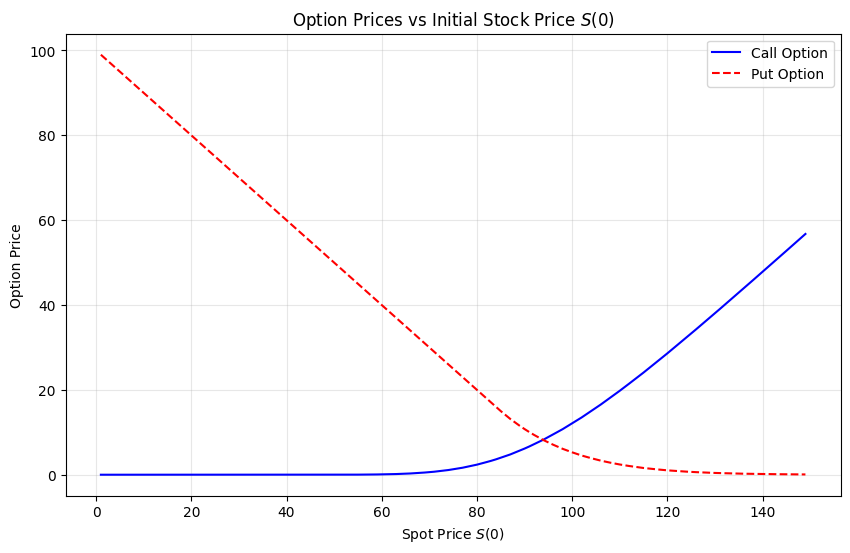

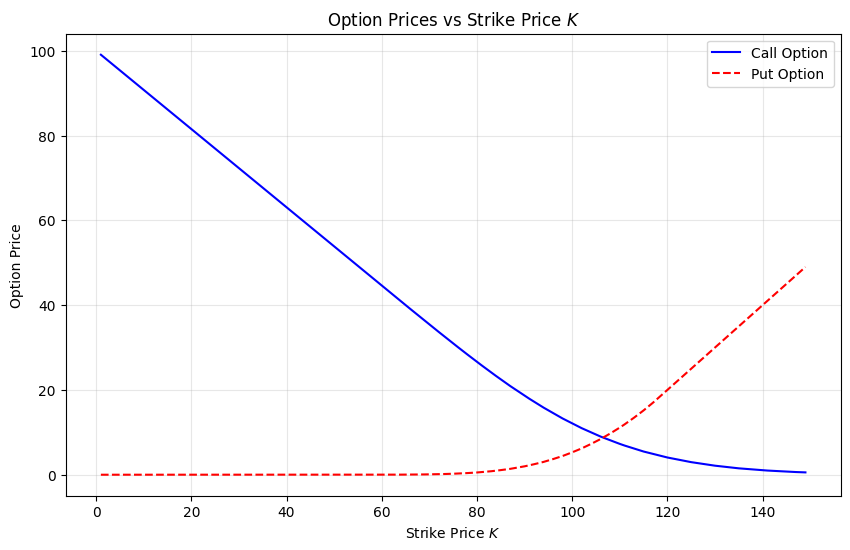

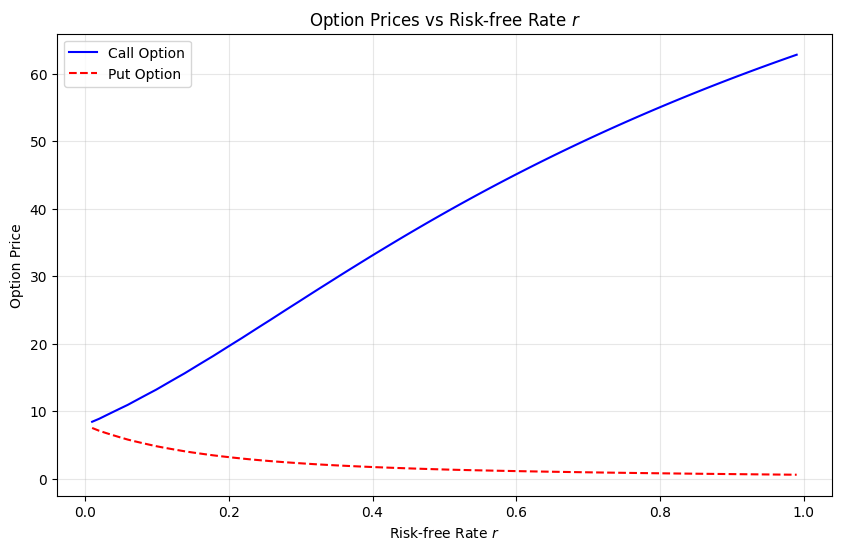

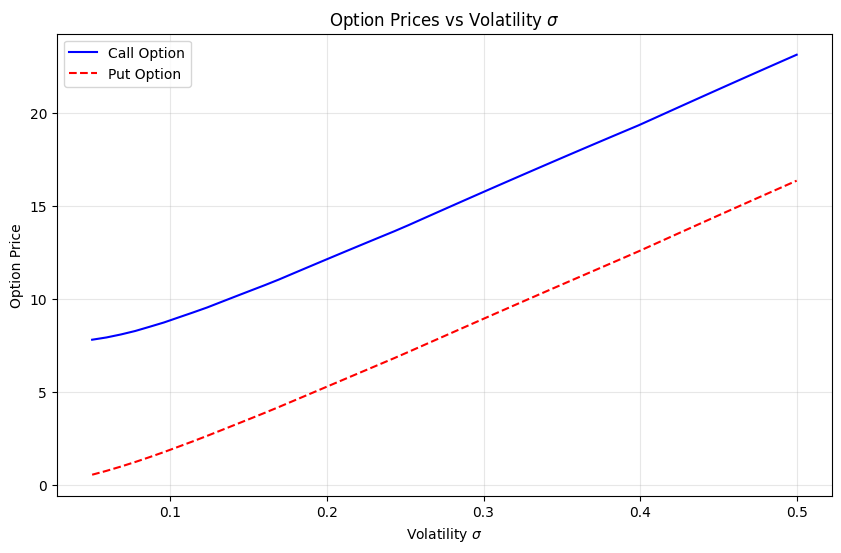

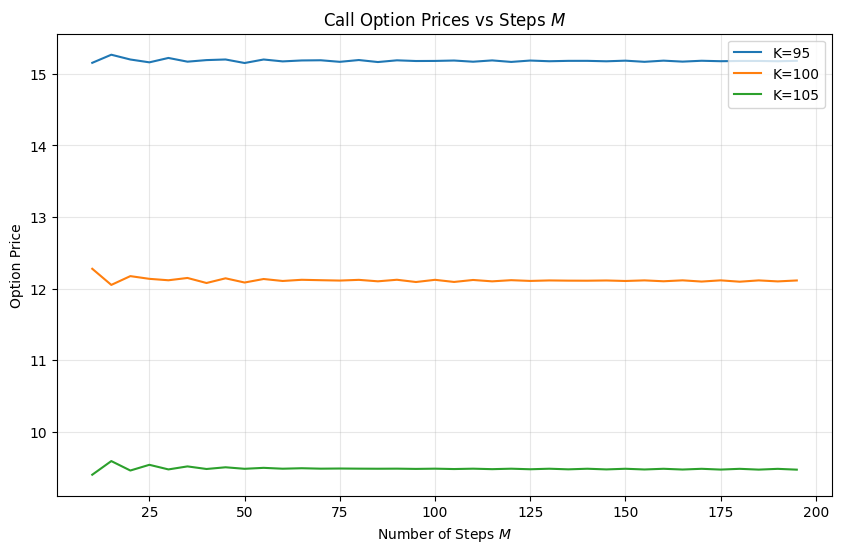

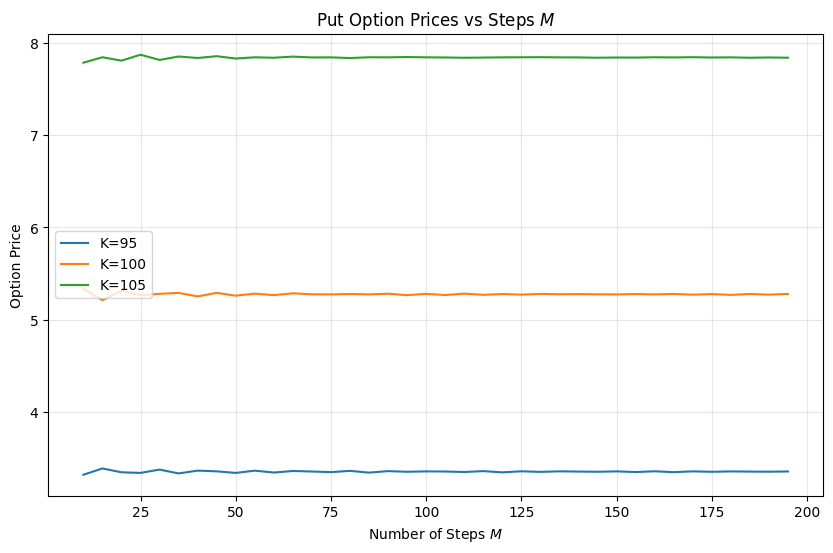

In [ ]:
def calculator(S_0,K,r,sigma,T,M):
    
    dt = T / M
    u=np.exp((sigma*np.sqrt(dt))+(r-0.5*(sigma*sigma))*dt)
    d=np.exp(-(sigma*np.sqrt(dt))+(r-0.5*(sigma*sigma))*dt)
    discount = np.exp(-r*dt)
    rate = np.exp(r*dt)
    p = (rate-d)/(u-d)
    
    lol=[]
    p=(rate-d)/(u-d)
    lol.append([S_0])
    for i in range(1,M+1):
        new_list=[]
        curr_list=lol[i-1]
        for j in range(len(lol[i-1])):
            new_list.append(curr_list[j]*u)
        new_list.append(curr_list[len(curr_list)-1]*d)
        lol.append(new_list)
    #backtrack
    end_value_call=[]
    end_value_put=[]
    for i in range(len(lol[-1])):
        end_value_call.append(max(lol[-1][i]-K,0))
        end_value_put.append(max(K-lol[-1][i],0))
    curr_val_call=end_value_call
    curr_val_put=end_value_put
    new_val_call=[]
    new_val_put=[]
    for i in range(M-1,-1,-1):
        for j in range(len(curr_val_call)-1):
            new_val_call.append(max(discount*(p*curr_val_call[j]+(1-p)*curr_val_call[j+1]),max(lol[i][j]-K,0)))
        curr_val_call=new_val_call
        new_val_call=[]
    for i in range(M-1,-1,-1):
        for j in range(len(curr_val_put)-1):
            new_val_put.append(max(discount*(p*curr_val_put[j]+(1-p)*curr_val_put[j+1]),max(K-lol[i][j],0)))
        curr_val_put=new_val_put
        new_val_put=[]
    final=[curr_val_call[0],curr_val_put[0]]
    return final



S_0=100
K=100
T=1
M=100
r=0.08
sigma=0.2

Ss = range(1, 150)
calls_S = []
puts_S = []

for s in Ss:
    get = calculator(s, K, r, sigma, T, M)
    calls_S.append(get[0])
    puts_S.append(get[1])

plt.figure(figsize=(10, 6))
plt.plot(Ss, calls_S, label='Call Option', color='blue')
plt.plot(Ss, puts_S, label='Put Option', color='red', linestyle='--')
plt.title('Option Prices vs Initial Stock Price $S(0)$')
plt.xlabel('Spot Price $S(0)$')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Ks = range(1, 150)
calls_K = []
puts_K = []

for k in Ks:
    get = calculator(S_0, k, r, sigma, T, M)
    calls_K.append(get[0])
    puts_K.append(get[1])

plt.figure(figsize=(10, 6))
plt.plot(Ks, calls_K, label='Call Option', color='blue')
plt.plot(Ks, puts_K, label='Put Option', color='red', linestyle='--')
plt.title('Option Prices vs Strike Price $K$')
plt.xlabel('Strike Price $K$')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

rs = np.linspace(0.01, 0.99, 100)
calls_r = []
puts_r = []

for rr in rs:
    get = calculator(S_0, K, rr, sigma, T, M)
    calls_r.append(get[0])
    puts_r.append(get[1])

plt.figure(figsize=(10, 6))
plt.plot(rs, calls_r, label='Call Option', color='blue')
plt.plot(rs, puts_r, label='Put Option', color='red', linestyle='--')
plt.title('Option Prices vs Risk-free Rate $r$')
plt.xlabel('Risk-free Rate $r$')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

sigmas = np.linspace(0.05, 0.5, 50)
calls_sig = []
puts_sig = []

for sig in sigmas:
    get = calculator(S_0, K, r, sig, T, M)
    calls_sig.append(get[0])
    puts_sig.append(get[1])

plt.figure(figsize=(10, 6))
plt.plot(sigmas, calls_sig, label='Call Option', color='blue')
plt.plot(sigmas, puts_sig, label='Put Option', color='red', linestyle='--')
plt.title(r'Option Prices vs Volatility $\sigma$')
plt.xlabel(r'Volatility $\sigma$')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Ms = range(10, 200, 5)
Ks_M = [95, 100, 105]

calls_M = {95: [], 100: [], 105: []}
puts_M = {95: [], 100: [], 105: []}

for k in Ks_M:
    for m in Ms:
        get = calculator(S_0, k, r, sigma, T, m)
        calls_M[k].append(get[0])
        puts_M[k].append(get[1])

plt.figure(figsize=(10, 6))
plt.plot(Ms, calls_M[95], label='K=95')
plt.plot(Ms, calls_M[100], label='K=100')
plt.plot(Ms, calls_M[105], label='K=105')
plt.title('Call Option Prices vs Steps $M$')
plt.xlabel('Number of Steps $M$')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plotting Put Options for varying M
plt.figure(figsize=(10, 6))
plt.plot(Ms, puts_M[95], label='K=95')
plt.plot(Ms, puts_M[100], label='K=100')
plt.plot(Ms, puts_M[105], label='K=105')
plt.title('Put Option Prices vs Steps $M$')
plt.xlabel('Number of Steps $M$')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
def calculator_all_points(S_0,K,r,sigma,T,M):
    
    dt = T / M
    u=np.exp((sigma*np.sqrt(dt))+(r-0.5*(sigma*sigma))*dt)
    d=np.exp(-(sigma*np.sqrt(dt))+(r-0.5*(sigma*sigma))*dt)
    discount = np.exp(-r*dt)
    rate = np.exp(r*dt)
    p = (rate-d)/(u-d)
    
    lol=[]
    p=(rate-d)/(u-d)
    lol.append([S_0])
    for i in range(1,M+1):
        new_list=[]
        curr_list=lol[i-1]
        for j in range(len(lol[i-1])):
            new_list.append(curr_list[j]*u)
        new_list.append(curr_list[len(curr_list)-1]*d)
        lol.append(new_list)
    #backtrack
    end_value_call=[]
    end_value_put=[]
    for i in range(len(lol[-1])):
        end_value_call.append(max(lol[-1][i]-K,0))
        end_value_put.append(max(K-lol[-1][i],0))
    curr_val_call=end_value_call
    curr_val_put=end_value_put
    put_prices=[[curr_val_put]]
    exercise_policy=[]
    new_val_call=[]
    new_val_put=[]

    for i in range(M-1,-1,-1):
        exercise_step=[]
        for j in range(len(curr_val_put)-1):
            cont_val=discount*(p*curr_val_put[j]+(1-p)*curr_val_put[j+1])
            exer_val=max(K-lol[i][j],0)
            new_val_put.append(max(cont_val,exer_val))
            exercise_step.append(exer_val>=cont_val)
        put_prices.append(new_val_put)
        exercise_policy.append(exercise_step)
        curr_val_put=new_val_put
        new_val_put=[]

    final=[curr_val_call[0],curr_val_put[0]]
    put_prices.reverse()
    exercise_policy.reverse()
    return put_prices,exercise_policy




S_0=100
K=100
T=1
M=5
r=0.08
sigma=0.2

prices,policy=calculator_all_points(S_0,K,r,sigma,T,M)
print(prices)
print(policy)

[[np.float64(5.330517073755082)], [np.float64(1.9716064645815858), np.float64(8.86178721922183)], [np.float64(0.3456100333696829), np.float64(3.6613995576984837), np.float64(14.348670443190741)], [np.float64(0.0), np.float64(0.7024104437776761), np.float64(6.738855931144315), np.float64(20.73140450617568)], [np.float64(0.0), np.float64(0.0), np.float64(1.4275639706333583), np.float64(12.268172420501472), np.float64(26.638497451508528)], [[0, 0, 0, np.float64(2.9013504971397026), np.float64(18.805945122887607), np.float64(32.10539403853048)]]]
[[np.False_], [np.False_, np.False_], [np.False_, np.False_, np.True_], [np.True_, np.False_, np.False_, np.True_], [np.True_, np.True_, np.False_, np.True_, np.True_]]
